In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [ ]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2021,12,28)
stk_data = gh(symbol='TATACOFFEE',start=start,end=end)


In [4]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [5]:
column="High"

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (2225, 1)


In [7]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [8]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,1,2),(1,2,3)]
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        from sklearn.metrics import r2_score
        mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

Lag=1,Trend=n
RMSE-Testset: 0.058859347313836866
maPe-Testset: 108221610722.61273
************
Lag=1,Trend=t
RMSE-Testset: 0.06567306536707392
maPe-Testset: 105694109653.11528
************
Lag=1,Trend=c
RMSE-Testset: 0.04336525033763366
maPe-Testset: 114804919729.45547
************
Lag=1,Trend=ct
RMSE-Testset: 0.1527369438632303
maPe-Testset: 74699776526.65292
************
Lag=2,Trend=n
RMSE-Testset: 0.05946957243778428
maPe-Testset: 107811149748.47528
************
Lag=2,Trend=t
RMSE-Testset: 0.053333877982384155
maPe-Testset: 110268940666.53214
************
Lag=2,Trend=c
RMSE-Testset: 0.03487154364942714
maPe-Testset: 119368707397.78128
************
Lag=2,Trend=ct
RMSE-Testset: 0.15147077869434786
maPe-Testset: 72770748055.74174
************
Lag=3,Trend=n
RMSE-Testset: 0.05944295500377151
maPe-Testset: 108331645493.58449
************
Lag=3,Trend=t
RMSE-Testset: 0.053497989920498146
maPe-Testset: 110722667896.76085
************
Lag=3,Trend=c
RMSE-Testset: 0.0360379925242156
maPe-Testse

C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

In [ ]:
len(y_pred)

In [9]:
i=2
td='c'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=2,Trend=c
RMSE-Testset: 0.03487154364942714
maPe-Testset: 119368707397.78128
************


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


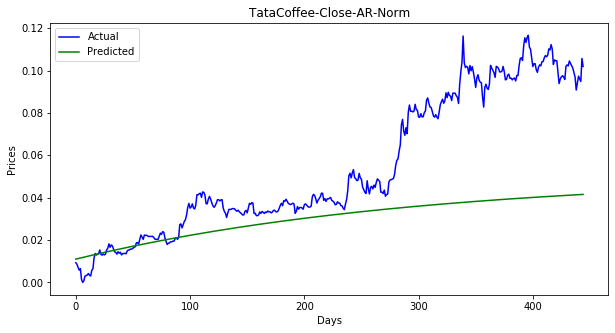

In [12]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-High-AR-Norm","Days","Prices")

In [ ]:
len(data1)

In [13]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [14]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

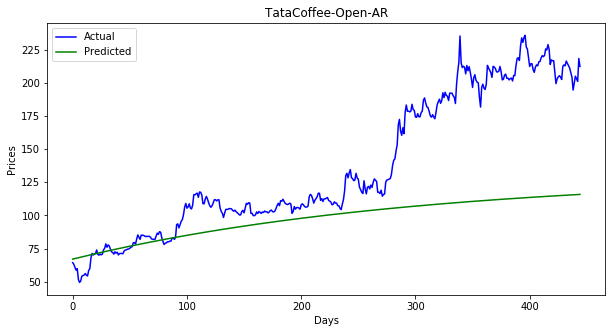

In [15]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-High-AR","Days","Prices")

In [16]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 55.7526239867041
maPe-Testset: 0.23324146264767795


In [17]:
forecast=model_fit.predict(len(data1), len(data1)+30)

In [18]:
forecast

array([0.04156393, 0.04159358, 0.04162314, 0.0416526 , 0.04168196,
       0.04171122, 0.04174038, 0.04176945, 0.04179841, 0.04182728,
       0.04185606, 0.04188474, 0.04191332, 0.0419418 , 0.04197019,
       0.04199849, 0.04202669, 0.04205479, 0.04208281, 0.04211072,
       0.04213855, 0.04216628, 0.04219392, 0.04222146, 0.04224892,
       0.04227628, 0.04230355, 0.04233073, 0.04235781, 0.04238481,
       0.04241172])

In [19]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Highfore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Highfore"])

In [20]:
forecast_stock_price_test_oriF

,Closefore
0,115.852
1,115.9
2,115.947
3,115.994
4,116.041
5,116.088
6,116.135
7,116.181
8,116.227
9,116.273


In [21]:
forecast_stock_price_test_oriF.to_csv("HighAR.csv",index=False)